# MuJoCo Warp Renderer Parity & Benchmarks

This notebook validates the Phase 1 renderer parity work and benchmarks the
mjwarp ray-traced renderer against `mujoco.Renderer` (OpenGL).

Each section exercises one of the lighting / material features wired up in
the Phase 1 PR:

1. **Headlight** — `vis.headlight` injection at the active camera\n
2. **Spotlight cutoff & exponent** — `light_cutoff`, `light_exponent`\n
3. **Distance attenuation** — `light_attenuation` 3-coefficient model\n
4. **Per-light color** — independent diffuse / specular per light\n
5. **Specular highlights** — Phong `mat_specular` / `mat_shininess`\n
6. **Material emission** — `mat_emission` self-illumination\n
7. **Shadows** — binary shadow rays

The final section times both renderers across resolutions and world counts.

> Run on a CUDA-enabled Warp build for meaningful multi-world benchmarks.
> On CPU the timings are still informative but rendering thousands of
> environments at once is not the design point.

## Setup

In [1]:
import time

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import warp as wp

import mujoco_warp as mjw

wp.init()
print("Warp devices:", [str(d) for d in wp.get_devices()])
print("CUDA devices:", wp.get_cuda_device_count())

Warp 1.13.0.dev20260227 initialized:
   Git commit: 0e622012c4291df7ad57cd8b6038d3498c6b5f60
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/mhasek/Library/Caches/warp/1.13.0.dev20260227
Warp devices: ['cpu']
CUDA devices: 0


In [2]:
def _unpack_rgb(packed: np.ndarray) -> np.ndarray:
  r = ((packed >> 16) & 0xFF).astype(np.uint8)
  g = ((packed >> 8) & 0xFF).astype(np.uint8)
  b = (packed & 0xFF).astype(np.uint8)
  return np.stack([r, g, b], axis=-1)


def mjwarp_render(
  mjm: mujoco.MjModel,
  w: int,
  h: int,
  use_shadows: bool = True,
  samples_per_pixel: int = 4,
) -> np.ndarray:
  """Render `mjm` with mjwarp at WxH. Returns an HxWx3 uint8 RGB image.

  Defaults match `mujoco.Renderer` for symmetric comparison: shadows are on
  (matching `mjRND_SHADOW`) and 4x MSAA is enabled. Pass `samples_per_pixel=1`
  for the raw single-sample output, or `use_shadows=False` to isolate the
  shading contribution.
  """
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(
    mjm,
    cam_res=(w, h),
    render_rgb=True,
    use_shadows=use_shadows,
    samples_per_pixel=samples_per_pixel,
  )
  mjw.render(m, d, rc)
  return _unpack_rgb(rc.rgb_data.numpy()[0]).reshape(h, w, 3)


def mujoco_render(mjm: mujoco.MjModel, w: int, h: int, use_shadows: bool = True) -> np.ndarray:
  """Render `mjm` with mujoco.Renderer at WxH. Returns an HxWx3 uint8 RGB image.

  Pass `use_shadows=False` to disable `mjRND_SHADOW` for symmetric comparison
  with mjwarp in shadow-off mode.
  """
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    r.update_scene(mjd, camera=0)
    r.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = 1 if use_shadows else 0
    return r.render()


def mean_l1(a: np.ndarray, b: np.ndarray) -> float:
  return float(np.abs(a.astype(np.float32) - b.astype(np.float32)).mean() / 255.0)


def ssim_luma(a: np.ndarray, b: np.ndarray, win: int = 8) -> float:
  """Compact box-window SSIM on luma. Same implementation as the parity tests."""
  ay = (0.299 * a[..., 0] + 0.587 * a[..., 1] + 0.114 * a[..., 2]).astype(np.float32) / 255.0
  by = (0.299 * b[..., 0] + 0.587 * b[..., 1] + 0.114 * b[..., 2]).astype(np.float32) / 255.0
  c1, c2 = (0.01) ** 2, (0.03) ** 2
  h, w = ay.shape
  hh, ww = h - h % win, w - w % win
  ay = ay[:hh, :ww].reshape(hh // win, win, ww // win, win)
  by = by[:hh, :ww].reshape(hh // win, win, ww // win, win)
  ay = ay.transpose(0, 2, 1, 3).reshape(-1, win * win)
  by = by.transpose(0, 2, 1, 3).reshape(-1, win * win)
  mu_a, mu_b = ay.mean(axis=1), by.mean(axis=1)
  va, vb = ay.var(axis=1), by.var(axis=1)
  cov = ((ay - mu_a[:, None]) * (by - mu_b[:, None])).mean(axis=1)
  num = (2 * mu_a * mu_b + c1) * (2 * cov + c2)
  den = (mu_a**2 + mu_b**2 + c1) * (va + vb + c2)
  return float((num / den).mean())


def compare_renders(title: str, mjm: mujoco.MjModel, w: int = 128, h: int = 128, use_shadows: bool = True):
  """Render `mjm` with both backends and plot side-by-side with diff and metrics.

  `use_shadows` is applied symmetrically to both renderers so the comparison
  isolates lighting / shading parity rather than shadow-flag asymmetry.
  """
  warp_rgb = mjwarp_render(mjm, w, h, use_shadows=use_shadows)
  mj_rgb = mujoco_render(mjm, w, h, use_shadows=use_shadows)
  diff = np.abs(warp_rgb.astype(np.int32) - mj_rgb.astype(np.int32)).clip(0, 255).astype(np.uint8)

  ssim = ssim_luma(warp_rgb, mj_rgb)
  l1 = mean_l1(warp_rgb, mj_rgb)

  fig, axes = plt.subplots(1, 3, figsize=(11, 4))
  axes[0].imshow(mj_rgb)
  axes[0].set_title("MuJoCo OpenGL")
  axes[0].axis("off")
  axes[1].imshow(warp_rgb)
  axes[1].set_title("mjwarp ray-traced")
  axes[1].axis("off")
  axes[2].imshow(diff)
  axes[2].set_title(f"|Δ| (max={int(diff.max())})")
  axes[2].axis("off")
  fig.suptitle(f"{title}   SSIM={ssim:.3f}   meanL1={l1:.3f}")
  plt.tight_layout()
  plt.show()
  return ssim, l1


# Canonical MSAA sweep values used across the notebook. The first column of every
# multi-N grid is the MuJoCo OpenGL reference (which already does its own MSAA);
# the rest are mjwarp at increasing samples_per_pixel.
MSAA_NS = (1, 2, 4, 8, 16)


def msaa_sweep_grid(
  title: str,
  mjm: mujoco.MjModel,
  w: int = 96,
  h: int = 96,
  use_shadows: bool = True,
  ns: tuple[int, ...] = MSAA_NS,
  cell_size: float = 1.8,
):
  """Render `mjm` once with MuJoCo OpenGL and once per N in `ns` with mjwarp.

  Plots them in a single row with SSIM(N) annotations. Returns a dict
  {N: (warp_rgb, ssim, l1)} for downstream tables / asserts.
  """
  mj_rgb = mujoco_render(mjm, w, h, use_shadows=use_shadows)
  results = {}
  for n in ns:
    warp_rgb = mjwarp_render(mjm, w, h, use_shadows=use_shadows, samples_per_pixel=n)
    results[n] = (warp_rgb, ssim_luma(warp_rgb, mj_rgb), mean_l1(warp_rgb, mj_rgb))

  fig, axes = plt.subplots(1, 1 + len(ns), figsize=(cell_size * (1 + len(ns)), cell_size + 0.6))
  axes[0].imshow(mj_rgb, interpolation="nearest")
  axes[0].set_title("MuJoCo OpenGL\n(ref)", fontsize=9)
  axes[0].axis("off")
  for col, n in enumerate(ns, start=1):
    warp_rgb, ssim, _ = results[n]
    axes[col].imshow(warp_rgb, interpolation="nearest")
    axes[col].set_title(f"mjwarp\nN={n}\nSSIM={ssim:.3f}", fontsize=9)
    axes[col].axis("off")
  fig.suptitle(title)
  plt.tight_layout()
  plt.show()
  return results


def msaa_sweep_table(label: str, results: dict[int, tuple]) -> None:
  """Print a compact SSIM / L1 vs N table for the dict returned by msaa_sweep_grid."""
  print(f"{label}")
  print(f"  {'N':>3s}  {'SSIM':>7s}  {'meanL1':>8s}")
  for n, (_, ssim, l1) in results.items():
    print(f"  {n:>3d}  {ssim:>7.4f}  {l1:>8.4f}")

## 1. Headlight injection

The default MuJoCo scene has no explicit lights but `vis.headlight.active = 1`.
The MuJoCo OpenGL renderer prepends the headlight as a directional light at
the active camera; the mjwarp renderer now does the same.

Before Phase 1 this scene rendered black in mjwarp (only the hemispheric
ambient hack lit anything). After Phase 1 it matches the OpenGL output. The
remaining minor difference comes from MuJoCo's MSAA-smoothed silhouette
vs mjwarp's ray-traced edges — softened in this notebook by the default
`samples_per_pixel=4` in `mjwarp_render` (see section 8a).

nlight = 0, headlight.active = 1
Module mujoco_warp._src.io 921ea14 load on device 'cpu' took 0.45 ms  (cached)
Module mujoco_warp._src.bvh e843d00 load on device 'cpu' took 0.20 ms  (cached)
Module render__locals___render_megakernel_c853587a 348e83f load on device 'cpu' took 0.20 ms  (cached)
Module render__locals___render_megakernel_7312c3bb b0bea8e load on device 'cpu' took 2.51 ms  (cached)
Module render__locals___render_megakernel_c058bc14 9c36155 load on device 'cpu' took 0.20 ms  (cached)
Module render__locals___render_megakernel_aad85c65 730d7f2 load on device 'cpu' took 0.45 ms  (cached)


Module render__locals___render_megakernel_3c06e1b1 af7870b load on device 'cpu' took 0.21 ms  (cached)


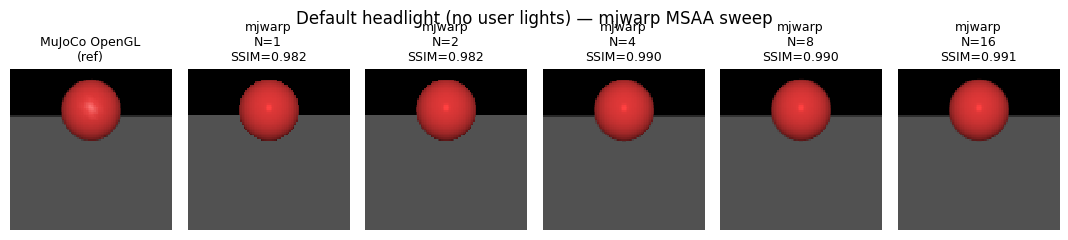

headlight_only
    N     SSIM    meanL1
    1   0.9819    0.0026
    2   0.9822    0.0026
    4   0.9897    0.0014
    8   0.9899    0.0015
   16   0.9905    0.0014


In [3]:
HEADLIGHT_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.3 0.3 0.3" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="128 128"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.6 0.6 0.6 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.2 0.2 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(HEADLIGHT_XML)
print(f"nlight = {mjm.nlight}, headlight.active = {mjm.vis.headlight.active}")
results = msaa_sweep_grid("Default headlight (no user lights) — mjwarp MSAA sweep", mjm, w=96, h=96)
msaa_sweep_table("headlight_only", results)

## 2. Spotlight cutoff & exponent sweep

Sweeping `cutoff` (cone half-angle, degrees) keeps the spotlight aimed
straight down and varies how wide the bright disk on the floor is. Sweeping
`exponent` controls how sharp the falloff is *within* the cone (higher =
tighter hotspot, lower = flat plateau).

Before Phase 1, mjwarp hardcoded `cutoff=18°/32°` and a linear ramp — every
spot light looked identical. Now both parameters drive the render.

Both renderers run with shadows on (the MuJoCo OpenGL default), so the
spherical occluder casts a visible shadow under itself in both panels.

Module render__locals___render_megakernel_f0adb2c9 14bb625 load on device 'cpu' took 0.23 ms  (cached)


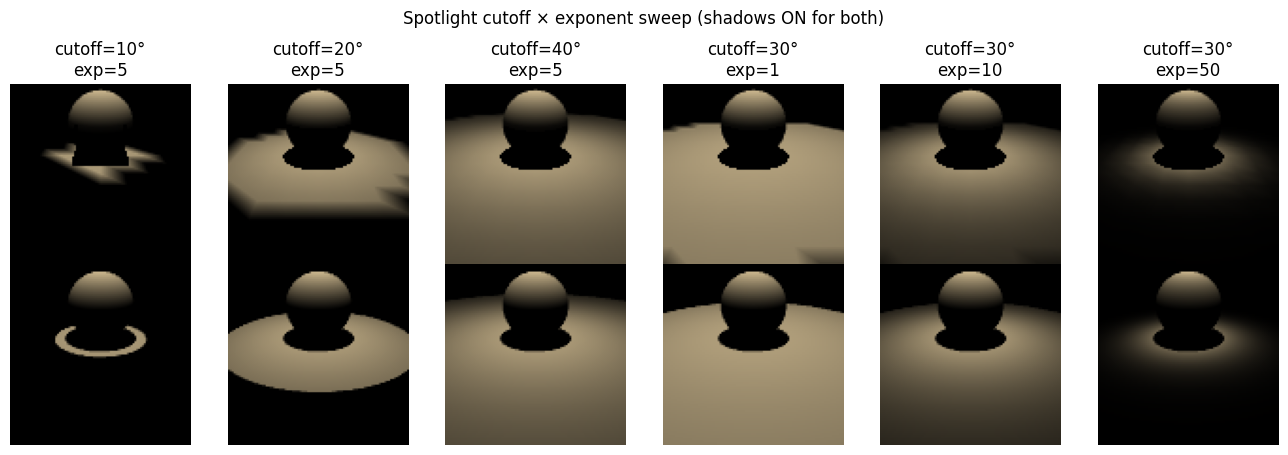

In [4]:
SPOT_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.5 1" resolution="96 96"/>
    <light pos="0 0 2.5" dir="0 0 -1" cutoff="{cutoff}" exponent="{exponent}"
           diffuse="1 0.9 0.7" specular="0 0 0" ambient="0 0 0" attenuation="1 0 0"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.8 0.8 1"/>
  </worldbody>
</mujoco>
"""

sweeps = [(10, 5), (20, 5), (40, 5), (30, 1), (30, 10), (30, 50)]
fig, axes = plt.subplots(2, len(sweeps), figsize=(2.2 * len(sweeps), 4.6))
for col, (cutoff, exponent) in enumerate(sweeps):
  mjm = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=cutoff, exponent=exponent))
  # Both renderers: shadows on, 4x MSAA (mjwarp) / MuJoCo's default MSAA (OpenGL).
  mj = mujoco_render(mjm, 96, 96, use_shadows=True)
  warp = mjwarp_render(mjm, 96, 96, use_shadows=True)
  axes[0, col].imshow(mj)
  axes[0, col].set_title(f"cutoff={cutoff}°\nexp={exponent}")
  axes[0, col].axis("off")
  axes[1, col].imshow(warp)
  axes[1, col].axis("off")
axes[0, 0].set_ylabel("MuJoCo", fontsize=10)
axes[1, 0].set_ylabel("mjwarp", fontsize=10)
fig.suptitle("Spotlight cutoff × exponent sweep (shadows ON for both)")
plt.tight_layout()
plt.show()

### Spotlight: MSAA sweep + shadow OFF vs shadow ON

Two follow-up comparisons on the same scene (`cutoff=20°, exponent=5`):

- **MSAA grid** sweeps `samples_per_pixel` from 1 → 16 with shadows on, so
  you can see how supersampling reduces the cone-boundary stair-step.
- **Shadow toggle** renders the scene in (shadow OFF, OFF) and (shadow ON,
  ON) so the shadow contribution is isolated from the lighting term.

Module render__locals___render_megakernel_810fccc2 93a28cf load on device 'cpu' took 0.27 ms  (cached)


Module render__locals___render_megakernel_d8013855 d897b0c load on device 'cpu' took 583.67 ms  (compiled)


Module render__locals___render_megakernel_25d3535d 6d2ea26 load on device 'cpu' took 621.35 ms  (compiled)


Module render__locals___render_megakernel_b4718337 d32744d load on device 'cpu' took 621.17 ms  (compiled)


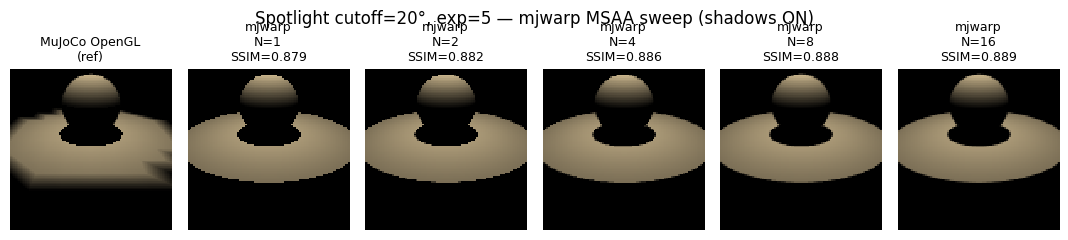

spotlight
    N     SSIM    meanL1
    1   0.8789    0.0207
    2   0.8818    0.0205
    4   0.8863    0.0199
    8   0.8883    0.0197
   16   0.8887    0.0196


In [5]:
mjm_spot_n = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=20, exponent=5))
results = msaa_sweep_grid(
  "Spotlight cutoff=20°, exp=5 — mjwarp MSAA sweep (shadows ON)",
  mjm_spot_n,
  w=96,
  h=96,
  use_shadows=True,
)
msaa_sweep_table("spotlight", results)

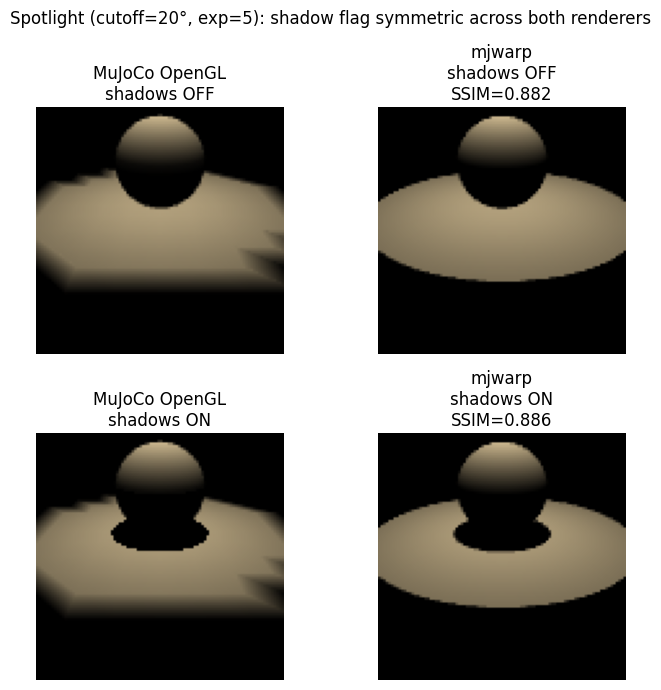

In [6]:
mjm_spot = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=20, exponent=5))

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for row, shadows in enumerate([False, True]):
  mj = mujoco_render(mjm_spot, 96, 96, use_shadows=shadows)
  warp = mjwarp_render(mjm_spot, 96, 96, use_shadows=shadows)
  ssim = ssim_luma(warp, mj)
  axes[row, 0].imshow(mj)
  axes[row, 0].set_title(f"MuJoCo OpenGL\nshadows {'ON' if shadows else 'OFF'}")
  axes[row, 0].axis("off")
  axes[row, 1].imshow(warp)
  axes[row, 1].set_title(f"mjwarp\nshadows {'ON' if shadows else 'OFF'}\nSSIM={ssim:.3f}")
  axes[row, 1].axis("off")
fig.suptitle("Spotlight (cutoff=20°, exp=5): shadow flag symmetric across both renderers")
plt.tight_layout()
plt.show()

## 3. Distance attenuation sweep

OpenGL's three-coefficient attenuation: `atten = 1 / (a0 + a1·d + a2·d²)`.
mjwarp used to hardcode `(1, 0, 0.02)` regardless of the model; now it reads
`light_attenuation` and matches OpenGL's behavior across coefficient choices.

Module render__locals___render_megakernel_cde20049 3aef673 load on device 'cpu' took 0.29 ms  (cached)


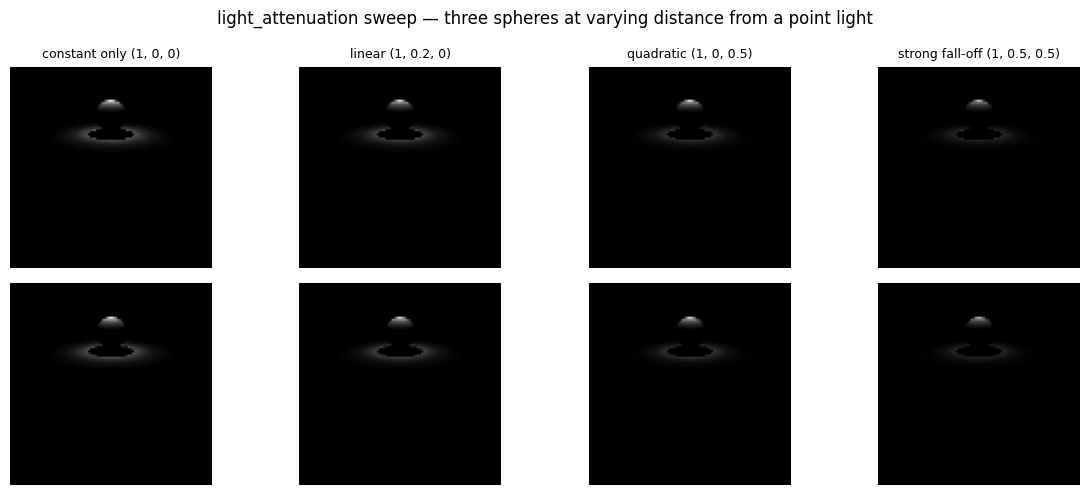

In [7]:
ATTEN_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -4 1" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <light pos="0 0 1" diffuse="1 1 1" specular="0 0 0" ambient="0 0 0" attenuation="{a0} {a1} {a2}"/>
    <geom name="floor" type="plane" size="3 3 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="b1" type="sphere" pos="-1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b2" type="sphere" pos=" 0   0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b3" type="sphere" pos=" 1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

attens = [
  ("constant only (1, 0, 0)", 1.0, 0.0, 0.0),
  ("linear (1, 0.2, 0)", 1.0, 0.2, 0.0),
  ("quadratic (1, 0, 0.5)", 1.0, 0.0, 0.5),
  ("strong fall-off (1, 0.5, 0.5)", 1.0, 0.5, 0.5),
]
fig, axes = plt.subplots(2, len(attens), figsize=(3 * len(attens), 5))
for col, (label, a0, a1, a2) in enumerate(attens):
  mjm = mujoco.MjModel.from_xml_string(ATTEN_XML.format(a0=a0, a1=a1, a2=a2))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(label, fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("light_attenuation sweep — three spheres at varying distance from a point light")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_39406fa1 5ea52c6 load on device 'cpu' took 557.98 ms  (compiled)


Module render__locals___render_megakernel_8a30bbe2 8b8539d load on device 'cpu' took 551.73 ms  (compiled)


Module render__locals___render_megakernel_ba1ccaa3 31ce4be load on device 'cpu' took 547.77 ms  (compiled)


Module render__locals___render_megakernel_9ee07f4c 221fe78 load on device 'cpu' took 540.02 ms  (compiled)


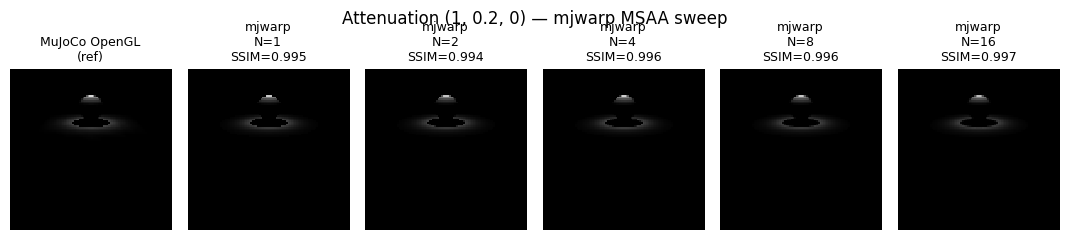

attenuation
    N     SSIM    meanL1
    1   0.9946    0.0006
    2   0.9943    0.0007
    4   0.9960    0.0006
    8   0.9961    0.0007
   16   0.9965    0.0006


In [8]:
mjm_atten_n = mujoco.MjModel.from_xml_string(ATTEN_XML.format(a0=1.0, a1=0.2, a2=0.0))
results = msaa_sweep_grid(
  "Attenuation (1, 0.2, 0) — mjwarp MSAA sweep",
  mjm_atten_n,
  w=96,
  h=96,
)
msaa_sweep_table("attenuation", results)

## 4. Per-light color

Two directional lights of distinct color (red and blue) should yield a
purple cross-illumination region in the middle and pure red / blue lobes on
the sides. Before Phase 1, all lights contributed identical white in
mjwarp.

Module render__locals___render_megakernel_b762d949 f59cd1e load on device 'cpu' took 0.22 ms  (cached)


Module render__locals___render_megakernel_99252655 4b16842 load on device 'cpu' took 579.16 ms  (compiled)
Module render__locals___render_megakernel_ebfe7364 eb38345 load on device 'cpu' took 0.25 ms  (cached)


Module render__locals___render_megakernel_e3101a51 a63858b load on device 'cpu' took 595.32 ms  (compiled)


Module render__locals___render_megakernel_6997616a ca06579 load on device 'cpu' took 583.62 ms  (compiled)


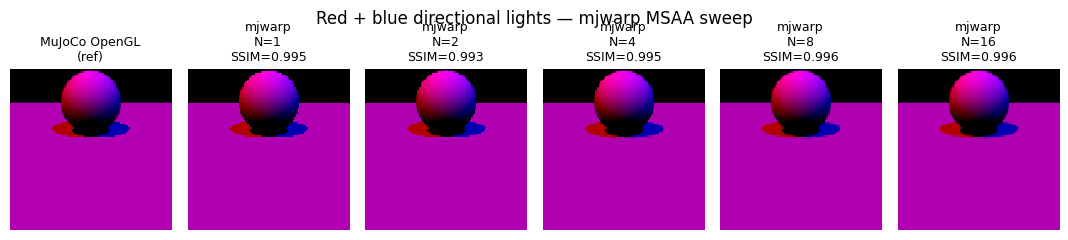

two_lights
    N     SSIM    meanL1
    1   0.9946    0.0038
    2   0.9928    0.0039
    4   0.9949    0.0039
    8   0.9960    0.0031
   16   0.9964    0.0031


In [9]:
TWO_LIGHTS_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="128 128"/>
    <light pos="-1 -1 2" dir="0.4 0.4 -1" directional="true" diffuse="1 0 0"
           specular="0 0 0" ambient="0 0 0"/>
    <light pos=" 1 -1 2" dir="-0.4 0.4 -1" directional="true" diffuse="0 0 1"
           specular="0 0 0" ambient="0 0 0"/>
    <geom type="plane" size="2 2 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(TWO_LIGHTS_XML)
results = msaa_sweep_grid("Red + blue directional lights — mjwarp MSAA sweep", mjm, w=96, h=96)
msaa_sweep_table("two_lights", results)

## 5. Specular highlights (Phong)

Sweeping `shininess` (stored in [0, 1], mapped to OpenGL exponent in
[0, 128]) controls the tightness of the highlight: low shininess = broad
soft highlight, high shininess = small intense hotspot.

Sweeping `specular` controls the highlight intensity.

Module render__locals___render_megakernel_67424983 2031ac8 load on device 'cpu' took 0.24 ms  (cached)


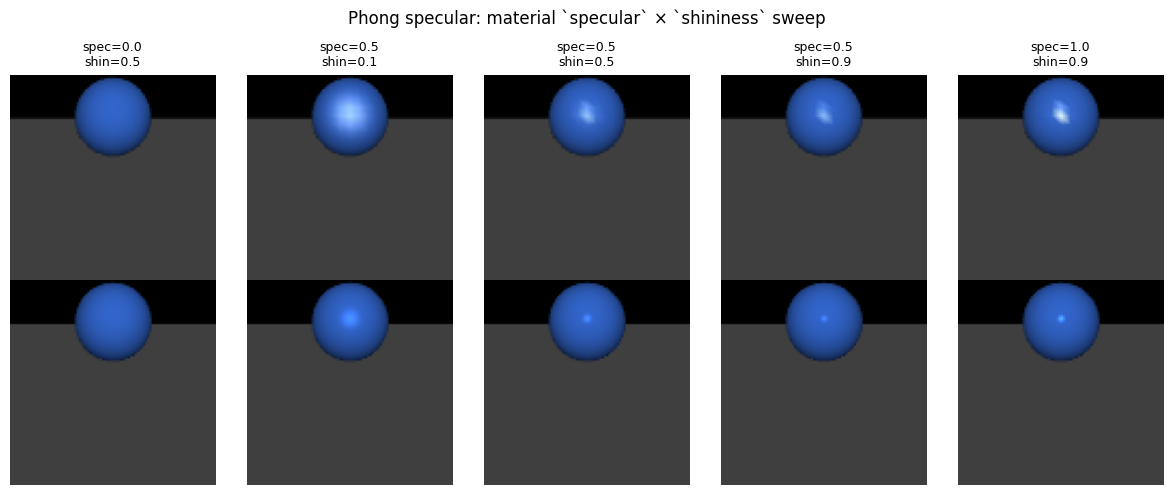

In [10]:
SPECULAR_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.9 0.9 0.9"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="m" specular="{spec}" shininess="{shin}" rgba="0.2 0.4 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.5 0.5 0.5 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="m"/>
  </worldbody>
</mujoco>
"""

specs = [(0.0, 0.5), (0.5, 0.1), (0.5, 0.5), (0.5, 0.9), (1.0, 0.9)]
fig, axes = plt.subplots(2, len(specs), figsize=(2.4 * len(specs), 5))
for col, (spec, shin) in enumerate(specs):
  mjm = mujoco.MjModel.from_xml_string(SPECULAR_XML.format(spec=spec, shin=shin))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"spec={spec}\nshin={shin}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("Phong specular: material `specular` × `shininess` sweep")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_9bfccb9b 16682e7 load on device 'cpu' took 0.23 ms  (cached)


Module render__locals___render_megakernel_3f7fafa9 07ab9a0 load on device 'cpu' took 485.53 ms  (compiled)


Module render__locals___render_megakernel_b4d2b0d1 8386a3e load on device 'cpu' took 508.82 ms  (compiled)


Module render__locals___render_megakernel_3bcde5c7 e77ce27 load on device 'cpu' took 491.39 ms  (compiled)


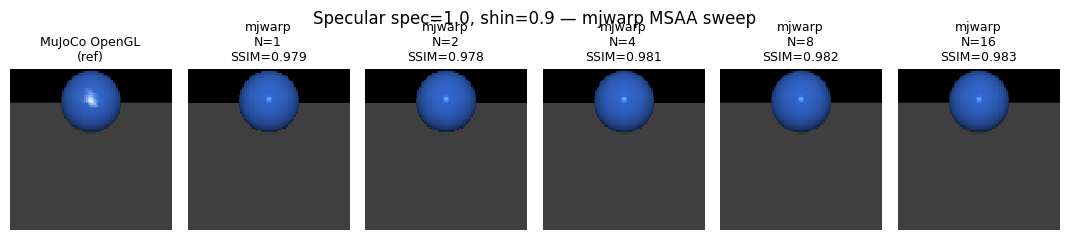

specular
    N     SSIM    meanL1
    1   0.9786    0.0026
    2   0.9779    0.0026
    4   0.9805    0.0024
    8   0.9820    0.0020
   16   0.9825    0.0020


In [11]:
mjm_spec_n = mujoco.MjModel.from_xml_string(SPECULAR_XML.format(spec=1.0, shin=0.9))
results = msaa_sweep_grid(
  "Specular spec=1.0, shin=0.9 — mjwarp MSAA sweep",
  mjm_spec_n,
  w=96,
  h=96,
)
msaa_sweep_table("specular", results)

## 6. Material emission

`mat_emission` is a scalar self-illumination factor. With no lights in the
scene and emission > 0, the geom should still be visible (and tinted by its
diffuse color).

Module render__locals___render_megakernel_54a78b80 81aa0cf load on device 'cpu' took 0.24 ms  (cached)


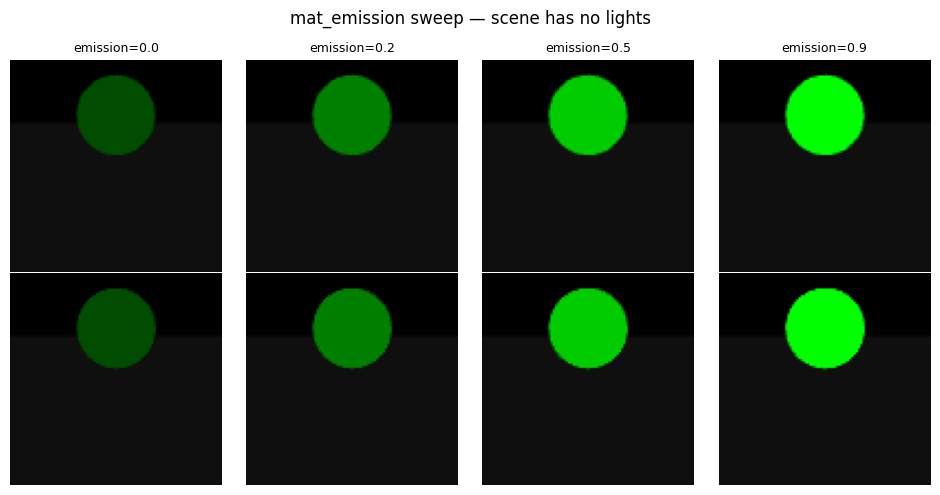

In [12]:
EMISSION_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="glow" emission="{emis}" rgba="0 1 0 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.2 0.2 0.2 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="glow"/>
  </worldbody>
</mujoco>
"""

emissions = [0.0, 0.2, 0.5, 0.9]
fig, axes = plt.subplots(2, len(emissions), figsize=(2.4 * len(emissions), 5))
for col, emis in enumerate(emissions):
  mjm = mujoco.MjModel.from_xml_string(EMISSION_XML.format(emis=emis))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"emission={emis}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("mat_emission sweep — scene has no lights")
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_55c7e779 002f2de load on device 'cpu' took 0.25 ms  (cached)


Module render__locals___render_megakernel_4523579b b0b7125 load on device 'cpu' took 466.35 ms  (compiled)


Module render__locals___render_megakernel_bda52d64 9ccd72d load on device 'cpu' took 466.73 ms  (compiled)


Module render__locals___render_megakernel_0bb9ff74 f333f6d load on device 'cpu' took 467.57 ms  (compiled)


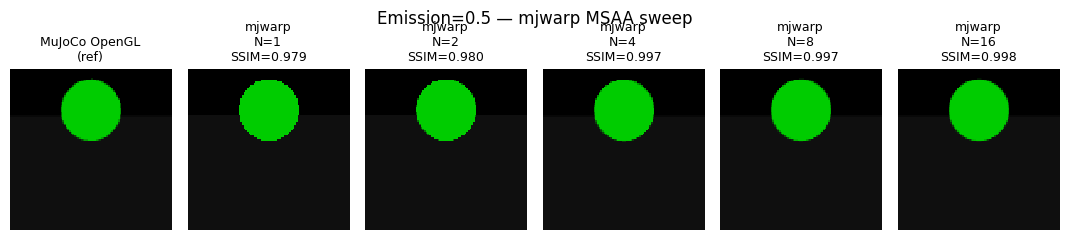

emission
    N     SSIM    meanL1
    1   0.9794    0.0010
    2   0.9801    0.0009
    4   0.9965    0.0005
    8   0.9969    0.0004
   16   0.9979    0.0004


In [13]:
mjm_emis_n = mujoco.MjModel.from_xml_string(EMISSION_XML.format(emis=0.5))
results = msaa_sweep_grid("Emission=0.5 — mjwarp MSAA sweep", mjm_emis_n, w=96, h=96)
msaa_sweep_table("emission", results)

## 7. Shadows

mjwarp's shadow rays produce geometrically exact, aliasing-free shadow
boundaries — strictly better than OpenGL shadow maps but not pixel-identical.
Phase 1 also changed mjwarp's shadow visibility from `0.3` (partial) to `0.0`
(binary), matching OpenGL.

The MuJoCo OpenGL renderer turns shadows on by default
(`scene.flags[mjRND_SHADOW] == 1`); mjwarp's `create_render_context` defaults
to `use_shadows=False` for performance. To make the comparison apples-to-
apples, the helpers in this notebook default `use_shadows=True` on both
backends and let you toggle them symmetrically.

The grid below shows the same scene rendered in **both renderers with
shadows OFF**, then **both with shadows ON**, so the renderer pair stays
symmetric and the shadow effect is isolated.

Module render__locals___render_megakernel_a855ee74 38663e6 load on device 'cpu' took 0.28 ms  (cached)


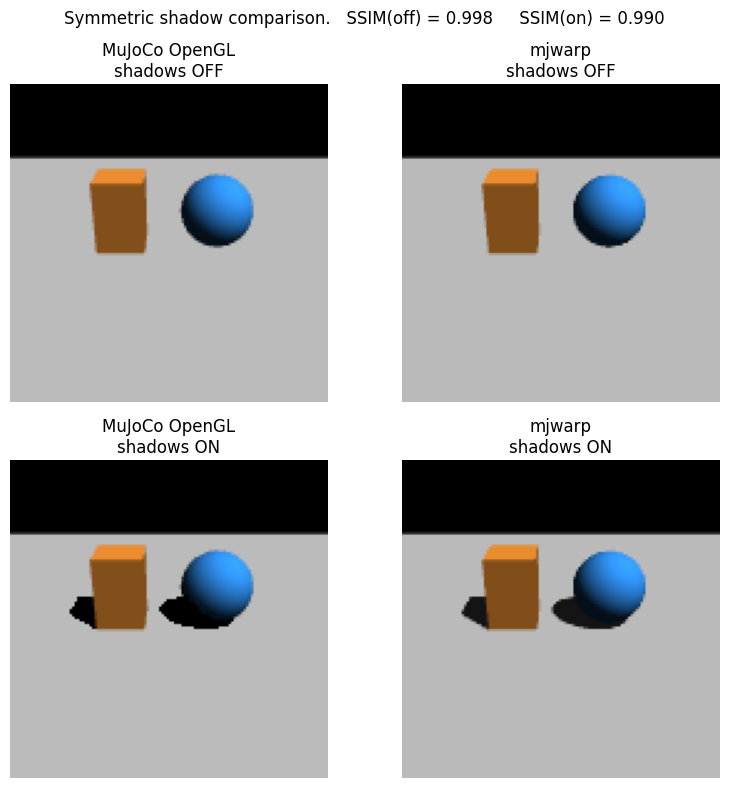

In [14]:
SHADOW_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
    <quality shadowsize="2048"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -3 1.5" xyaxes="1 0 0 0 0.5 1" resolution="128 128"/>
    <light pos="2 -2 4" dir="-0.5 0.5 -1" directional="true" castshadow="true"
           diffuse="1 1 1" specular="0 0 0" ambient="0.1 0.1 0.1"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box" pos="-0.4 0 0.3" size="0.2 0.2 0.3" rgba="1 0.6 0.2 1"/>
    <geom type="sphere" pos="0.4 0 0.3" size="0.3" rgba="0.2 0.6 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(SHADOW_XML)

# Render both backends in both shadow modes (off, off) and (on, on) so the
# comparison stays symmetric — turning shadows on in only one of the two
# renderers would create a false discrepancy in regions occluded by geometry.
mj_off = mujoco_render(mjm, 128, 128, use_shadows=False)
warp_off = mjwarp_render(mjm, 128, 128, use_shadows=False)
mj_on = mujoco_render(mjm, 128, 128, use_shadows=True)
warp_on = mjwarp_render(mjm, 128, 128, use_shadows=True)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(mj_off)
axes[0, 0].set_title("MuJoCo OpenGL\nshadows OFF")
axes[0, 0].axis("off")
axes[0, 1].imshow(warp_off)
axes[0, 1].set_title("mjwarp\nshadows OFF")
axes[0, 1].axis("off")
axes[1, 0].imshow(mj_on)
axes[1, 0].set_title("MuJoCo OpenGL\nshadows ON")
axes[1, 0].axis("off")
axes[1, 1].imshow(warp_on)
axes[1, 1].set_title("mjwarp\nshadows ON")
axes[1, 1].axis("off")

ssim_off = ssim_luma(warp_off, mj_off)
ssim_on = ssim_luma(warp_on, mj_on)
fig.suptitle(
  "Symmetric shadow comparison.   "
  f"SSIM(off) = {ssim_off:.3f}     SSIM(on) = {ssim_on:.3f}"
)
plt.tight_layout()
plt.show()

Module render__locals___render_megakernel_f5a3c739 fe45a45 load on device 'cpu' took 560.27 ms  (compiled)


Module render__locals___render_megakernel_a5d54f34 c8e9cc0 load on device 'cpu' took 545.15 ms  (compiled)


Module render__locals___render_megakernel_f9f091ef 574b876 load on device 'cpu' took 550.71 ms  (compiled)


Module render__locals___render_megakernel_98265048 ba9c1e1 load on device 'cpu' took 556.06 ms  (compiled)


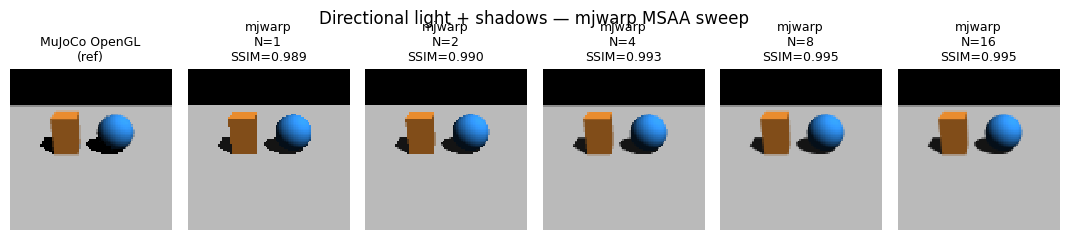

shadows
    N     SSIM    meanL1
    1   0.9890    0.0077
    2   0.9898    0.0078
    4   0.9934    0.0056
    8   0.9947    0.0056
   16   0.9952    0.0055


In [15]:
mjm_shadow_n = mujoco.MjModel.from_xml_string(SHADOW_XML)
results = msaa_sweep_grid(
  "Directional light + shadows — mjwarp MSAA sweep",
  mjm_shadow_n,
  w=96,
  h=96,
  use_shadows=True,
)
msaa_sweep_table("shadows", results)

## 8. Supersample anti-aliasing (MSAA)

A single ray per pixel produces visible stair-stepping along geom
silhouettes. `create_render_context(samples_per_pixel=N)` fires N jittered
rays per pixel using a Halton(2, 3) low-discrepancy pattern and averages the
results, producing smooth silhouettes at proportionally higher shading cost.

The sweep below uses a low resolution (32×32) so the aliasing at N=1 is
obvious, then shows N=4 and N=16. The MuJoCo OpenGL reference is on the left
for comparison.

Module render__locals___render_megakernel_b784d3df 671f481 load on device 'cpu' took 0.28 ms  (cached)
Module render__locals___render_megakernel_74561415 dc11bcf load on device 'cpu' took 0.27 ms  (cached)
Module render__locals___render_megakernel_dce1cc97 2b359c9 load on device 'cpu' took 0.23 ms  (cached)
Module render__locals___render_megakernel_4c16ef45 66c5683 load on device 'cpu' took 0.24 ms  (cached)


Module render__locals___render_megakernel_376d5031 9213a7b load on device 'cpu' took 0.23 ms  (cached)


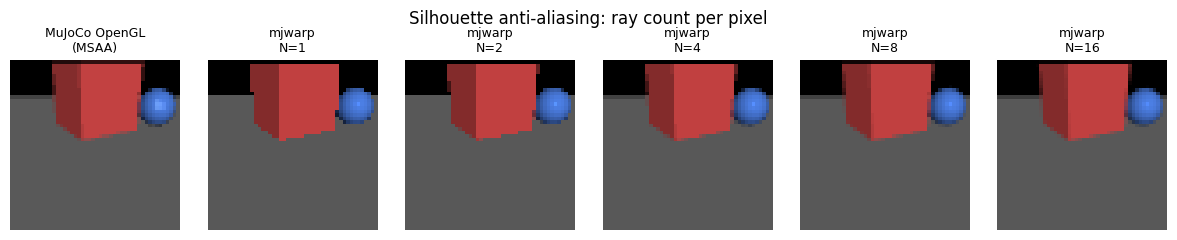

In [16]:
MSAA_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="48 48"/>
    <geom type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom type="box" pos="0 0 0.3" size="0.3 0.3 0.3" euler="0 0 30" rgba="0.9 0.3 0.3 1"/>
    <geom type="sphere" pos="0.6 0 0.2" size="0.18" rgba="0.3 0.5 0.9 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(MSAA_XML)
mj = mujoco_render(mjm, 48, 48)

samples = [1, 2, 4, 8, 16]
fig, axes = plt.subplots(1, len(samples) + 1, figsize=(2.0 * (len(samples) + 1), 2.4))
axes[0].imshow(mj, interpolation="nearest")
axes[0].set_title("MuJoCo OpenGL\n(MSAA)", fontsize=9)
axes[0].axis("off")
for col, n in enumerate(samples, start=1):
  img = mjwarp_render(mjm, 48, 48, samples_per_pixel=n)
  axes[col].imshow(img, interpolation="nearest")
  axes[col].set_title(f"mjwarp\nN={n}", fontsize=9)
  axes[col].axis("off")
fig.suptitle("Silhouette anti-aliasing: ray count per pixel")
plt.tight_layout()
plt.show()

### MSAA cost

MSAA scales linearly with `samples_per_pixel` since each sample re-casts a
primary ray and re-evaluates the full shading chain. Background pixels are
cheaper than hit pixels.

In [17]:
def bench_msaa(mjm, w, h, n_samples):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(mjm, cam_res=(w, h), render_rgb=True, samples_per_pixel=n_samples)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  # warm up to compile the kernel for this N
  for _ in range(2):
    step()
  ts = []
  for _ in range(5):
    t0 = time.perf_counter()
    step()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


mjm_bench_msaa = mujoco.MjModel.from_xml_string(MSAA_XML)
ns = [1, 2, 4, 8, 16]
times = [bench_msaa(mjm_bench_msaa, 128, 128, n) for n in ns]
print(f"{'N':>3s}  {'time (ms)':>10s}  {'cost/sample (ms)':>17s}")
for n, t in zip(ns, times):
  print(f"{n:>3d}  {t * 1000:>10.2f}  {t * 1000 / n:>17.3f}")

  N   time (ms)   cost/sample (ms)
  1       11.69             11.689
  2       12.65              6.327
  4       14.12              3.531
  8       16.84              2.105
 16       21.93              1.371


## 9. SSIM summary across all canonical fixtures

Aggregate parity numbers for the same fixtures used in
`render_parity_test.py`, with mjwarp evaluated at each `samples_per_pixel`
in the canonical MSAA sweep. The N=1 column reflects the renderer's
production default (no MSAA, single ray per pixel); higher Ns show how
much of the residual gap to MuJoCo OpenGL comes from aliasing alone.

In [18]:
from mujoco_warp._src.render_parity_test import (
  _FIXTURE_EMISSION,
  _FIXTURE_HEADLIGHT_ONLY,
  _FIXTURE_SPECULAR,
  _FIXTURE_SPOTLIGHT,
  _FIXTURE_TWO_LIGHTS,
)

fixtures = [
  ("headlight_only", _FIXTURE_HEADLIGHT_ONLY),
  ("spotlight", _FIXTURE_SPOTLIGHT),
  ("specular", _FIXTURE_SPECULAR),
  ("two_lights", _FIXTURE_TWO_LIGHTS),
  ("emission", _FIXTURE_EMISSION),
]

# fixture -> {N: (ssim, meanL1)}
ssim_table = {}
for name, xml in fixtures:
  mjm = mujoco.MjModel.from_xml_string(xml)
  mj_rgb = mujoco_render(mjm, 64, 64)
  by_n = {}
  for n in MSAA_NS:
    warp_rgb = mjwarp_render(mjm, 64, 64, samples_per_pixel=n)
    by_n[n] = (ssim_luma(warp_rgb, mj_rgb), mean_l1(warp_rgb, mj_rgb))
  ssim_table[name] = by_n

header_n = "  ".join(f"N={n:<2d}" for n in MSAA_NS)
print(f"SSIM vs MuJoCo OpenGL (higher is better):")
print(f"  {'fixture':<18s}  {header_n}")
for name, by_n in ssim_table.items():
  cells = "  ".join(f"{by_n[n][0]:>5.3f}" for n in MSAA_NS)
  print(f"  {name:<18s}  {cells}")

print()
print(f"mean L1 vs MuJoCo OpenGL (lower is better):")
print(f"  {'fixture':<18s}  {header_n}")
for name, by_n in ssim_table.items():
  cells = "  ".join(f"{by_n[n][1]:>5.3f}" for n in MSAA_NS)
  print(f"  {name:<18s}  {cells}")

SSIM vs MuJoCo OpenGL (higher is better):
  fixture             N=1   N=2   N=4   N=8   N=16
  headlight_only      0.983  0.983  0.988  0.988  0.989
  spotlight           0.917  0.921  0.928  0.931  0.932
  specular            0.968  0.970  0.974  0.977  0.977
  two_lights          0.994  0.993  0.995  0.997  0.997
  emission            0.994  0.995  0.997  0.996  0.997

mean L1 vs MuJoCo OpenGL (lower is better):
  fixture             N=1   N=2   N=4   N=8   N=16
  headlight_only      0.002  0.002  0.002  0.002  0.001
  spotlight           0.016  0.016  0.015  0.015  0.015
  specular            0.003  0.003  0.003  0.003  0.003
  two_lights          0.005  0.005  0.005  0.004  0.004
  emission            0.002  0.002  0.001  0.001  0.001


## 10. Performance benchmarks

Comparing the two renderers on the same scene at increasing image
resolutions, world counts, and `samples_per_pixel` values. The MSAA
dimension is added to each existing benchmark so the cost / quality
tradeoff is visible across all three perf axes.

Each measurement is the median of `n_repeats` runs after a warmup, so the
first kernel compile is excluded.

> On CPU-only Warp builds the multi-world numbers are not representative of
> production GPU throughput; they're shown to verify the kernel scales
> linearly with world count rather than catastrophically.

In [19]:
BENCH_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.7 0.7 0.7" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="shiny" specular="0.7" shininess="0.6" rgba="0.4 0.5 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="64 64"/>
    <light pos="1 -1 2" dir="-0.4 0.5 -1" diffuse="0.8 0.8 0.7" specular="0.5 0.5 0.5"
           ambient="0.05 0.05 0.05" attenuation="1 0 0" castshadow="false"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box"     pos="-0.6 0 0.25" size="0.2 0.2 0.25" material="shiny"/>
    <geom type="sphere"  pos=" 0   0 0.30" size="0.30" material="shiny"/>
    <geom type="capsule" pos=" 0.6 0 0.30" size="0.15 0.15" material="shiny"/>
  </worldbody>
</mujoco>
"""


def time_call(fn, n_warmup: int = 2, n_repeats: int = 5) -> float:
  for _ in range(n_warmup):
    fn()
  ts = []
  for _ in range(n_repeats):
    t0 = time.perf_counter()
    fn()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


def bench_mujoco(mjm, w, h, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    def step():
      r.update_scene(mjd, camera=0)
      r.render()
    return time_call(step, n_warmup, n_repeats)


def bench_mjwarp(mjm, w, h, nworld=1, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=False)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  return time_call(step, n_warmup, n_repeats)

### Resolution sweep — single-world, MSAA sweep

`mujoco.Renderer` only renders one scene at a time. mjwarp's per-world cost
is dominated by `total_rays = W·H · samples_per_pixel` per camera, so we
expect roughly linear growth with pixel count and with sample count. The
chart plots one line per `N ∈ MSAA_NS` so you can read the cost of both
dimensions at once.

Module render__locals___render_megakernel_a37a2206 32e3ef1 load on device 'cpu' took 0.28 ms  (cached)


Module render__locals___render_megakernel_a0f85660 0587125 load on device 'cpu' took 577.37 ms  (compiled)


Module render__locals___render_megakernel_ca28c9b0 3330add load on device 'cpu' took 604.54 ms  (compiled)


Module render__locals___render_megakernel_2123d4b9 8f11cac load on device 'cpu' took 611.60 ms  (compiled)


Module render__locals___render_megakernel_aeada344 4d80b75 load on device 'cpu' took 574.76 ms  (compiled)


backend                   32²    64²    96²   128²   192²   256²
  mujoco.Renderer        0.65   0.36   0.36   0.34   0.39   0.40
  mjwarp N=1            11.04  11.21  11.96  13.10  16.70  21.21
  mjwarp N=2            10.93  11.54  12.95  14.84  20.96  28.56
  mjwarp N=4            11.10  12.47  15.16  18.93  28.38  43.00
  mjwarp N=8            11.86  14.34  19.11  25.47  43.72  69.82
  mjwarp N=16           12.40  17.76  28.16  44.28  78.40  130.25


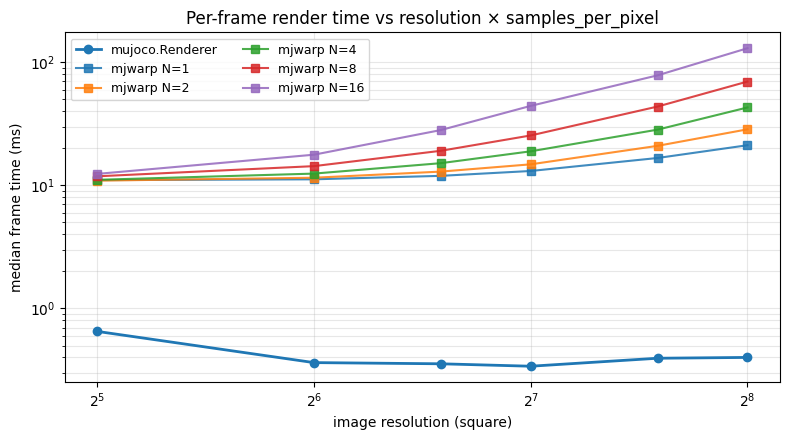

In [20]:
def bench_mjwarp_n(mjm, w, h, nworld=1, samples_per_pixel=1, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(
    mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=False, samples_per_pixel=samples_per_pixel
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step, n_warmup, n_repeats)


mjm_bench = mujoco.MjModel.from_xml_string(BENCH_XML)
resolutions = [32, 64, 96, 128, 192, 256]

mj_times = [bench_mujoco(mjm_bench, r, r) for r in resolutions]
warp_times_by_n = {n: [bench_mjwarp_n(mjm_bench, r, r, nworld=1, samples_per_pixel=n) for r in resolutions] for n in MSAA_NS}

header_res = "  ".join(f"{r:>4d}²" for r in resolutions)
print(f"{'backend':<22s}  {header_res}")
mj_row = "  ".join(f"{t * 1000:>5.2f}" for t in mj_times)
print(f"  {'mujoco.Renderer':<20s}  {mj_row}")
for n in MSAA_NS:
  row = "  ".join(f"{t * 1000:>5.2f}" for t in warp_times_by_n[n])
  print(f"  {'mjwarp N=' + str(n):<20s}  {row}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(resolutions, np.array(mj_times) * 1000, "o-", label="mujoco.Renderer", color="C0", linewidth=2)
for n in MSAA_NS:
  ax.plot(resolutions, np.array(warp_times_by_n[n]) * 1000, "s-", label=f"mjwarp N={n}", alpha=0.85)
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("median frame time (ms)")
ax.set_title("Per-frame render time vs resolution × samples_per_pixel")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

### World-count scaling — mjwarp only, with MSAA dimension

`mujoco.Renderer` can't batch worlds, so this scaling chart only applies to
mjwarp. We expect throughput in frames/sec to grow with world count on a
healthy GPU (the kernel parallelizes over both worlds and rays), bottoming
out only when the device saturates.

One line per `samples_per_pixel`. Adjust `world_counts` based on your
hardware. On CPU we cap at small values to keep the notebook responsive.

per-world cost (ms) at 64×64:
  samples     w=   1  w=   4  w=  16  w=  64
  N=1         11.919   3.559   1.441   0.885
  N=2         11.859   3.832   1.810   1.291
  N=4         13.246   4.820   2.886   2.169
  N=8         14.452   6.369   4.426   3.913
  N=16        17.760   9.964   7.871   7.327


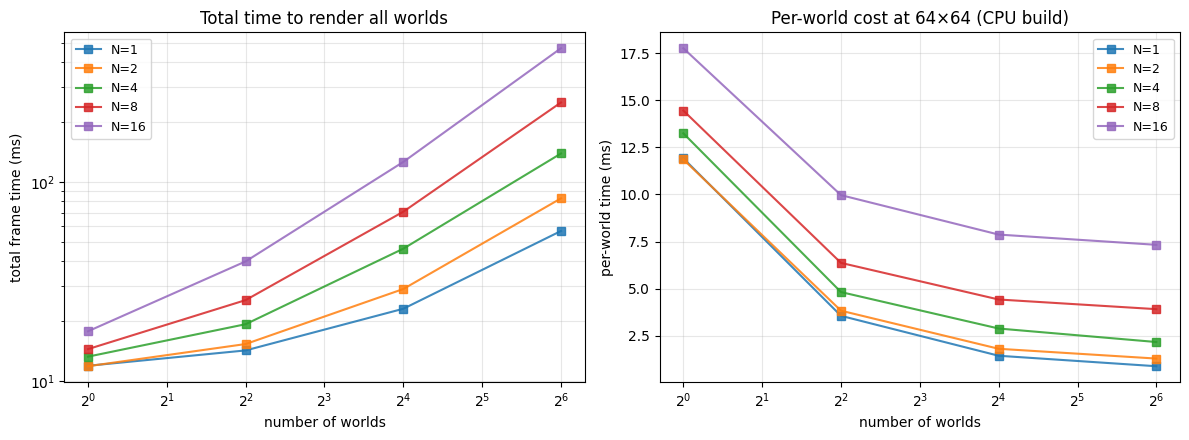

In [21]:
has_cuda = wp.get_cuda_device_count() > 0
if has_cuda:
  world_counts = [1, 4, 16, 64, 256, 1024]
else:
  world_counts = [1, 4, 16, 64]

cam_w = cam_h = 64

# frames[N] = list of total times (one per nworld in world_counts)
frame_times_by_n = {n: [bench_mjwarp_n(mjm_bench, cam_w, cam_h, nworld=w, samples_per_pixel=n) for w in world_counts] for n in MSAA_NS}

header_world = "  ".join(f"w={w:>4d}" for w in world_counts)
print(f"per-world cost (ms) at {cam_w}×{cam_h}:")
print(f"  {'samples':<10s}  {header_world}")
for n in MSAA_NS:
  per_world = [t * 1000 / w for t, w in zip(frame_times_by_n[n], world_counts)]
  row = "  ".join(f"{v:>6.3f}" for v in per_world)
  print(f"  {'N=' + str(n):<10s}  {row}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for n in MSAA_NS:
  axes[0].plot(world_counts, np.array(frame_times_by_n[n]) * 1000, "s-", label=f"N={n}", alpha=0.85)
axes[0].set_xlabel("number of worlds")
axes[0].set_ylabel("total frame time (ms)")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_title("Total time to render all worlds")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=9)

for n in MSAA_NS:
  per_world = np.array(frame_times_by_n[n]) * 1000 / np.array(world_counts)
  axes[1].plot(world_counts, per_world, "s-", label=f"N={n}", alpha=0.85)
axes[1].set_xlabel("number of worlds")
axes[1].set_ylabel("per-world time (ms)")
axes[1].set_xscale("log", base=2)
axes[1].set_title(f"Per-world cost at {cam_w}×{cam_h} ({'CUDA' if has_cuda else 'CPU'} build)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Shadow cost × MSAA

Enabling shadows roughly doubles per-pixel work because every lit pixel
casts an additional shadow ray per active light. With MSAA, that extra
shadow ray is fired per sub-pixel sample, so the shadow overhead also
scales with `samples_per_pixel`. This cell quantifies both axes on the
benchmark scene.

res         N    off (ms)   on (ms)  on/off


  64x64    N=1     11.51    11.24   0.98x


  64x64    N=2     11.53    12.11   1.05x
  64x64    N=4     12.45    13.00   1.04x


  64x64    N=8     14.13    15.20   1.08x


  64x64    N=16    17.93    20.05   1.12x


...

 256x256   N=1     21.86    27.32   1.25x


 256x256   N=2     28.61    32.94   1.15x


 256x256   N=4     42.57    50.13   1.18x


 256x256   N=8     69.12    84.85   1.23x


 256x256   N=16   124.56   155.69   1.25x


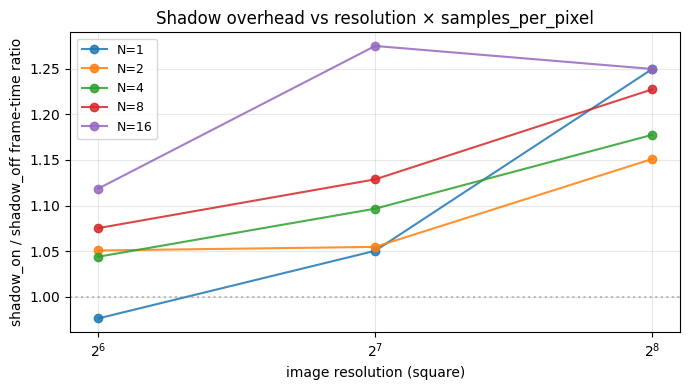

In [22]:
SHADOW_BENCH_XML = BENCH_XML.replace('castshadow="false"', 'castshadow="true"')
mjm_shadow = mujoco.MjModel.from_xml_string(SHADOW_BENCH_XML)


def bench_mjwarp_shadows(mjm, w, h, use_shadows: bool, samples_per_pixel: int = 1, nworld: int = 1):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(
    mjm,
    nworld=nworld,
    cam_res=(w, h),
    render_rgb=True,
    use_shadows=use_shadows,
    samples_per_pixel=samples_per_pixel,
  )

  def step():
    mjw.render(m, d, rc)
    wp.synchronize()

  return time_call(step)


shadow_res = [64, 128, 256]
ratios = {n: [] for n in MSAA_NS}
print(f"{'res':<10s}  {'N':<3s}  {'off (ms)':>8s}  {'on (ms)':>8s}  {'on/off':>6s}")
for r in shadow_res:
  for n in MSAA_NS:
    t_off = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=False, samples_per_pixel=n)
    t_on = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=True, samples_per_pixel=n)
    ratios[n].append(t_on / t_off)
    print(f"{r:>4d}x{r:<4d}  N={n:<2d}  {t_off * 1000:>7.2f}  {t_on * 1000:>7.2f}  {t_on / t_off:>5.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
for n in MSAA_NS:
  ax.plot(shadow_res, ratios[n], "o-", label=f"N={n}", alpha=0.85)
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("shadow_on / shadow_off frame-time ratio")
ax.set_title("Shadow overhead vs resolution × samples_per_pixel")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", alpha=0.3)
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary

If all the side-by-side comparisons above show mjwarp tracking MuJoCo OpenGL
qualitatively (and the SSIM table at section 8 is all green), the Phase 1
parity work is functioning end-to-end on this build.

Remaining differences in the diff panels (e.g. the spot cone boundary,
ball silhouette, specular hotspot shape) are structural consequences of
per-pixel ray tracing vs per-vertex Gouraud shading and cannot be fully
closed without changing the rasterized reference itself. Phase 2/3 will
*widen* the gap in mjwarp's favor (soft shadows, Fresnel, GGX) — Phase 1's
goal was just to make mjwarp respond to the same knobs that OpenGL does.